In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.layers as tfl
from tensorflow.keras.models import Sequential, Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Visualizing CIFAR-10

In [2]:
def plot_category_images(category, n_images=9, data = "train"):
    plt.figure(figsize=(10,10))
    plt.title(category)
    
    rows = int(np.sqrt(n_images))
    image_dir = os.path.join("data", data, category)
    images = os.listdir(image_dir)
    np.random.shuffle(images)

    for i in range(rows**2):
        image = plt.imread(os.path.join(image_dir, images[i]))
        plt.subplot(rows, rows, i+1)
        if i==0:
            plt.title(category)
        
        plt.imshow(image)
        plt.axis("off")
    
    plt.show()

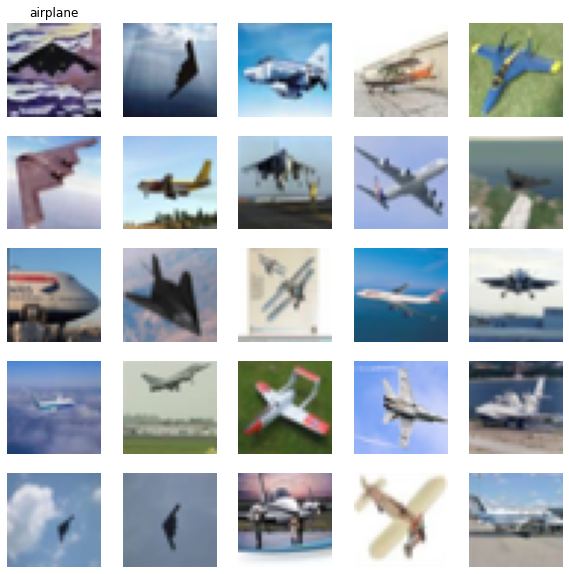

In [3]:
plot_category_images("airplane", n_images=30)

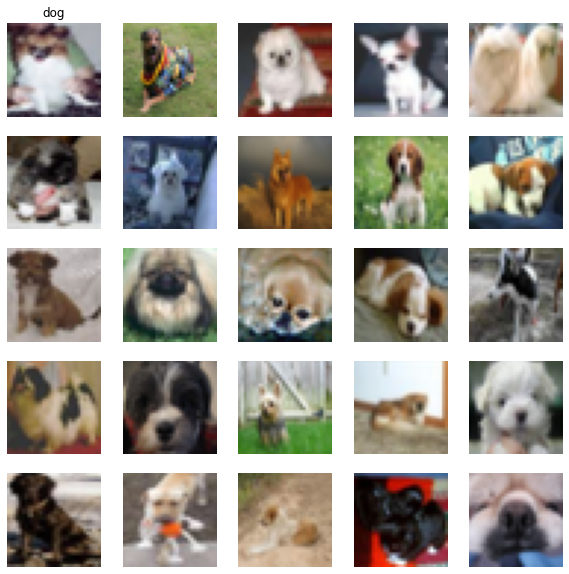

In [4]:
plot_category_images("dog", n_images=25)

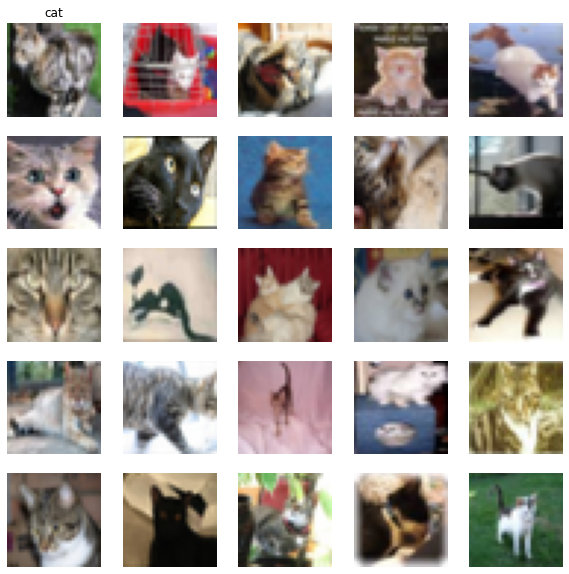

In [5]:
plot_category_images("cat", n_images=25)

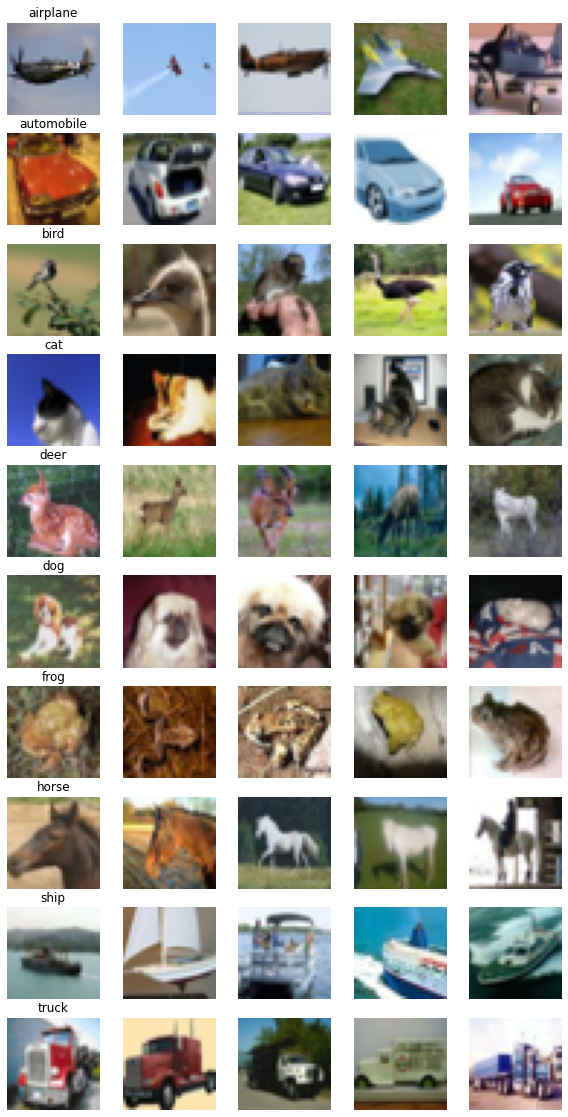

In [6]:
categories = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
plt.figure(figsize= (10,20))

img = 0
for j, cat in enumerate(categories):
    cat_dir = os.path.join("data", "train", cat)
    cat_images = os.listdir(cat_dir)
    np.random.shuffle(cat_images)

    for i in range(5):
        image = plt.imread(os.path.join(cat_dir, cat_images[i]))
        img+=1
        plt.subplot(10,5,img)
        if i ==0:
            plt.title(cat)
        plt.imshow(image)
        plt.axis("off")

It is obviuos that the CIFAR-10 dataset are really blurry. Even a human will make a lot of mistakes. Let's see how well our model can do.

## NN Models

### Loading The Data

In [7]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

170498071/170498071 [==============================] - 164s 1us/step


In [12]:
y_test = y_test.flatten()
b = np.zeros((y_test.size, y_test.max()+1))
b[np.arange(y_test.size),y_test] = 1
y_test = b

y_train = y_train.flatten()
b = np.zeros((y_train.size, y_train.max()+1))
b[np.arange(y_train.size),y_train] = 1
y_train = b

All good!

### Simple NN

In [13]:
model_0 = Sequential(
    [
        tfl.Flatten(input_shape=(32,32,3)),
        tfl.Dense(256, activation="relu"),
        tfl.Dense(128, activation="relu"),
        # tfl.Dense(256, activation="relu"),
        tfl.Dense(10, activation="sigmoid"),
    ]
)

model_0.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 3072)              0         
                                                                 
 dense_3 (Dense)             (None, 256)               786688    
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 820,874
Trainable params: 820,874
Non-trainable params: 0
_________________________________________________________________


In [14]:
model_0.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_0 = model_0.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10


2022-08-01 17:39:34.832387: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 153600000 exceeds 10% of free system memory.


1558/1563 [============================>.] - ETA: 0s - loss: 18.5098 - accuracy: 0.1993

2022-08-01 17:39:44.369873: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 30720000 exceeds 10% of free system memory.


1563/1563 [==============================] - 10s 6ms/step - loss: 18.4629 - accuracy: 0.1992 - val_loss: 2.0888 - val_accuracy: 0.2295
Epoch 2/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.1714 - accuracy: 0.2239 - val_loss: 2.3955 - val_accuracy: 0.2373
Epoch 3/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.2715 - accuracy: 0.1453 - val_loss: 2.3042 - val_accuracy: 0.1000
Epoch 4/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3046 - accuracy: 0.0982 - val_loss: 2.3034 - val_accuracy: 0.0998
Epoch 5/10
 384/1563 [======>.......................] - ETA: 7s - loss: 2.3040 - accuracy: 0.0994

KeyboardInterrupt: 

In [17]:
input = tfl.Input(shape=(32,32,3))
x = tfl.Conv2D(32, (3,3), activation="relu")(input)
x = tfl.MaxPooling2D((2,2))(x)
x = tfl.Conv2D(64, (3,3), activation="relu")(x)
x = tfl.MaxPooling2D((2,2))(x)
x = tfl.Conv2D(128, (3,3), activation="relu")(x)
x = tfl.MaxPooling2D((2,2))(x)
x = tfl.Flatten()(x)
x = tfl.Dense(128, activation="relu")(x)
x = tfl.Dense(10, activation="sigmoid")(x)
model = Model(input, x)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 32, 32, 3)]       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 13, 13, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 4, 4, 128)         73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 2, 2, 128)         0     

In [18]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [19]:
model.fit(train_data, epochs=10, batch_size=64, validation_data=test_data)

Epoch 1/10
750/750 [==============================] - 113s 142ms/step - loss: 1.8325 - accuracy: 0.4129 - val_loss: 1.3429 - val_accuracy: 0.5210
Epoch 2/10
750/750 [==============================] - 111s 144ms/step - loss: 1.2684 - accuracy: 0.5508 - val_loss: 1.2085 - val_accuracy: 0.5835
Epoch 3/10
750/750 [==============================] - 123s 159ms/step - loss: 1.1225 - accuracy: 0.6059 - val_loss: 1.1158 - val_accuracy: 0.6050
Epoch 4/10
750/750 [==============================] - 119s 152ms/step - loss: 1.0145 - accuracy: 0.6452 - val_loss: 1.0905 - val_accuracy: 0.6320
Epoch 5/10
750/750 [==============================] - 124s 154ms/step - loss: 0.9381 - accuracy: 0.6730 - val_loss: 1.0238 - val_accuracy: 0.6525
Epoch 6/10
750/750 [==============================] - 105s 134ms/step - loss: 0.8723 - accuracy: 0.6951 - val_loss: 1.0324 - val_accuracy: 0.6610
Epoch 7/10
750/750 [==============================] - 107s 138ms/step - loss: 0.8091 - accuracy: 0.7201 - val_loss: 1.0547 -

In [5]:
zeros = np.zeros((len(y_train), 10))
zeros[np.arange(len(y_train)), y_train[:, 0]] = 1
y_train = zeros

zeros = np.zeros((len(y_test), 10))
zeros[np.arange(len(y_test)), y_test[:, 0]] = 1
y_test = zeros

In [10]:
x_test = x_test.astype("float32") / 255.0
x_train = x_train.astype("float32") / 255.0

In [26]:
model = tf.keras.models.load_model(r"C:\Users\harik\Downloads\model.h5")

In [12]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 35s 95ms/step - loss: 0.5371 - accuracy: 0.86101s - loss: 0


[0.5371211767196655, 0.8610000014305115]

In [13]:
model.evaluate(x_train, y_train)

1563/1563 [==============================] - 93s 58ms/step - loss: 0.0160 - accuracy: 0.99781s - - ETA: 0s - loss: 0.0160  - ETA: 0s - loss: 0.0160 - 


[0.016036245971918106, 0.9978200197219849]

In [14]:
# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (32, 32)
BATCH_SIZE = 32

# train_dir = "10_food_classes_10_percent/train/"
test_dir = "data/test/"

# train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# print("Training images:")
# train_data_10_percent = train_datagen.flow_from_directory(train_dir,
#                                                target_size=IMAGE_SHAPE,
#                                                batch_size=BATCH_SIZE,
#                                                class_mode="categorical")

print("Testing images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                              target_size=IMAGE_SHAPE,
                                              batch_size=BATCH_SIZE,
                                              class_mode="categorical")

Testing images:
Found 0 images belonging to 0 classes.


In [7]:
import os

In [8]:
files = os.listdir(test_dir)

In [9]:
len(files)

300000

In [14]:
import matplotlib.pyplot as plt

In [15]:
plt.imread(os.path.join(test_dir, files[0]))

array([[[0.5254902 , 0.45490196, 0.30588236],
        [0.5647059 , 0.49803922, 0.35686275],
        [0.5686275 , 0.5019608 , 0.36078432],
        ...,
        [0.50980395, 0.42745098, 0.28235295],
        [0.50980395, 0.43137255, 0.3019608 ],
        [0.49019608, 0.41960785, 0.29803923]],

       [[0.5568628 , 0.49019608, 0.34117648],
        [0.57254905, 0.5137255 , 0.37254903],
        [0.5764706 , 0.5254902 , 0.3882353 ],
        ...,
        [0.54509807, 0.44313726, 0.28627452],
        [0.5529412 , 0.46666667, 0.32156864],
        [0.52156866, 0.4392157 , 0.3137255 ]],

       [[0.56078434, 0.5176471 , 0.34117648],
        [0.6       , 0.57254905, 0.35686275],
        [0.5882353 , 0.57254905, 0.3647059 ],
        ...,
        [0.5568628 , 0.4627451 , 0.30588236],
        [0.5411765 , 0.45490196, 0.3137255 ],
        [0.5254902 , 0.4509804 , 0.32941177]],

       ...,

       [[0.56078434, 0.5058824 , 0.49019608],
        [0.6039216 , 0.4392157 , 0.40784314],
        [0.62352943, 0

In [17]:
import tqdm

In [18]:
import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
data_dir = "data/test"
files= os.listdir(data_dir)
img = plt.imread(os.path.join(data_dir, files[0]))
file_num = int(files[0].split(".")[0])
img = img.reshape(1, 32, 32, 3)

In [25]:
data_dir = "data/test"
files= os.listdir(data_dir)
img_files = np.zeros((len(files), 32, 32, 3), dtype=np.uint8)
for file in tqdm.tqdm(files, desc="Adding..."):
    img = plt.imread(os.path.join(data_dir, file))
    file_num = int(file.split(".")[0])
    img = img.reshape(1, 32, 32, 3)
#     img = img/255.
    img_files[file_num-1] = img

Adding...: 100%|██████████| 300000/300000 [09:36<00:00, 520.23it/s]


In [30]:
pd.DataFrame(img_files.reshape(300000, 32*32*3)).to_csv(r"C:\Users\harik\Downloads\test_data.csv")

In [39]:
img_files = img_files*255

In [40]:
preds = model.predict(img_files)

In [41]:
from life_saving_tools.Notification import Notification

In [42]:
n= Notification()
n.send_whatsapp_text("Done!")

SM89f752ca60094d67be57056c719e6687


In [32]:
preds.shape

(300000, 10)

In [43]:
pd.DataFrame(preds).to_csv(r"C:\Users\harik\Downloads\preds.csv")

In [44]:
preds.argmax(axis=1)

array([4, 0, 4, ..., 4, 4, 0], dtype=int64)

In [3]:
preds = pd.read_csv(r"C:\Users\harik\Downloads\preds.csv")

In [12]:
cols = np.arange(0,10)